###Install dependencies

In [ ]:
!nvidia-smi

Thu Sep 28 16:11:19 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.105.17   Driver Version: 525.105.17   CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   47C    P8    10W /  70W |      0MiB / 15360MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [ ]:
!pip install ultralytics==8.0.20

from IPython import display
display.clear_output()

import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.0.20 🚀 Python-3.10.12 torch-2.0.1+cu118 CUDA:0 (Tesla T4, 15102MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 26.3/78.2 GB disk)


In [ ]:
from ultralytics import YOLO

from IPython.display import display, Image

In [ ]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets
!pip install roboflow --quiet

from roboflow import Roboflow

/content/datasets
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.3/155.3 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 MB 11.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 kB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.3/63.3 kB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 6.5 MB/s eta 0:00:00


###Download Dataset

In [ ]:
rf = Roboflow(api_key="your-roboflow-token")
project = rf.workspace("product-detection-4zkyw").project("market-products-detection")
dataset = project.version(4).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...
Dependency ultralytics==8.0.134 is required but found version=8.0.20, to fix: `pip install ultralytics==8.0.134`



Extracting Dataset Version Zip to Market-Products-Detection-4 in yolov8:: 100%|██████████| 6426/6426 [00:02<00:00, 2908.76it/s]


###Train Model

In [ ]:
%cd {HOME}

!yolo task=detect mode=train model=yolov8m.pt data={dataset.location}/data.yaml epochs=120 imgsz=244 plots=True

/content
100% 49.7M/49.7M [00:00<00:00, 75.3MB/s]

Ultralytics YOLOv8.0.20 🚀 Python-3.10.12 torch-2.0.1+cu118 CUDA:0 (Tesla T4, 15102MiB)
yolo/engine/trainer: task=detect, mode=train, model=yolov8m.yaml, data=/content/datasets/Market-Products-Detection-4/data.yaml, epochs=120, patience=50, batch=16, imgsz=244, save=True, cache=False, device=, workers=8, project=None, name=None, exist_ok=False, pretrained=False, optimizer=SGD, verbose=True, seed=0, deterministic=True, single_cls=False, image_weights=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, overlap_mask=True, mask_ratio=4, dropout=False, val=True, save_json=False, save_hybrid=False, conf=0.001, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=ultralytics/assets/, show=False, save_txt=False, save_conf=False, save_crop=False, hide_labels=False, hide_conf=False, vid_stride=1, line_thickness=3, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, boxes=True, format=torchs

####Train Results

In [ ]:
!ls {HOME}/runs/detect/train/

args.yaml					   train_batch20350.jpg
confusion_matrix.png				   train_batch20351.jpg
events.out.tfevents.1695917555.e4e998428c5e.659.0  train_batch20352.jpg
F1_curve.png					   train_batch2.jpg
P_curve.png					   val_batch0_labels.jpg
PR_curve.png					   val_batch0_pred.jpg
R_curve.png					   val_batch1_labels.jpg
results.csv					   val_batch1_pred.jpg
results.png					   val_batch2_labels.jpg
train_batch0.jpg				   val_batch2_pred.jpg
train_batch1.jpg				   weights


/content


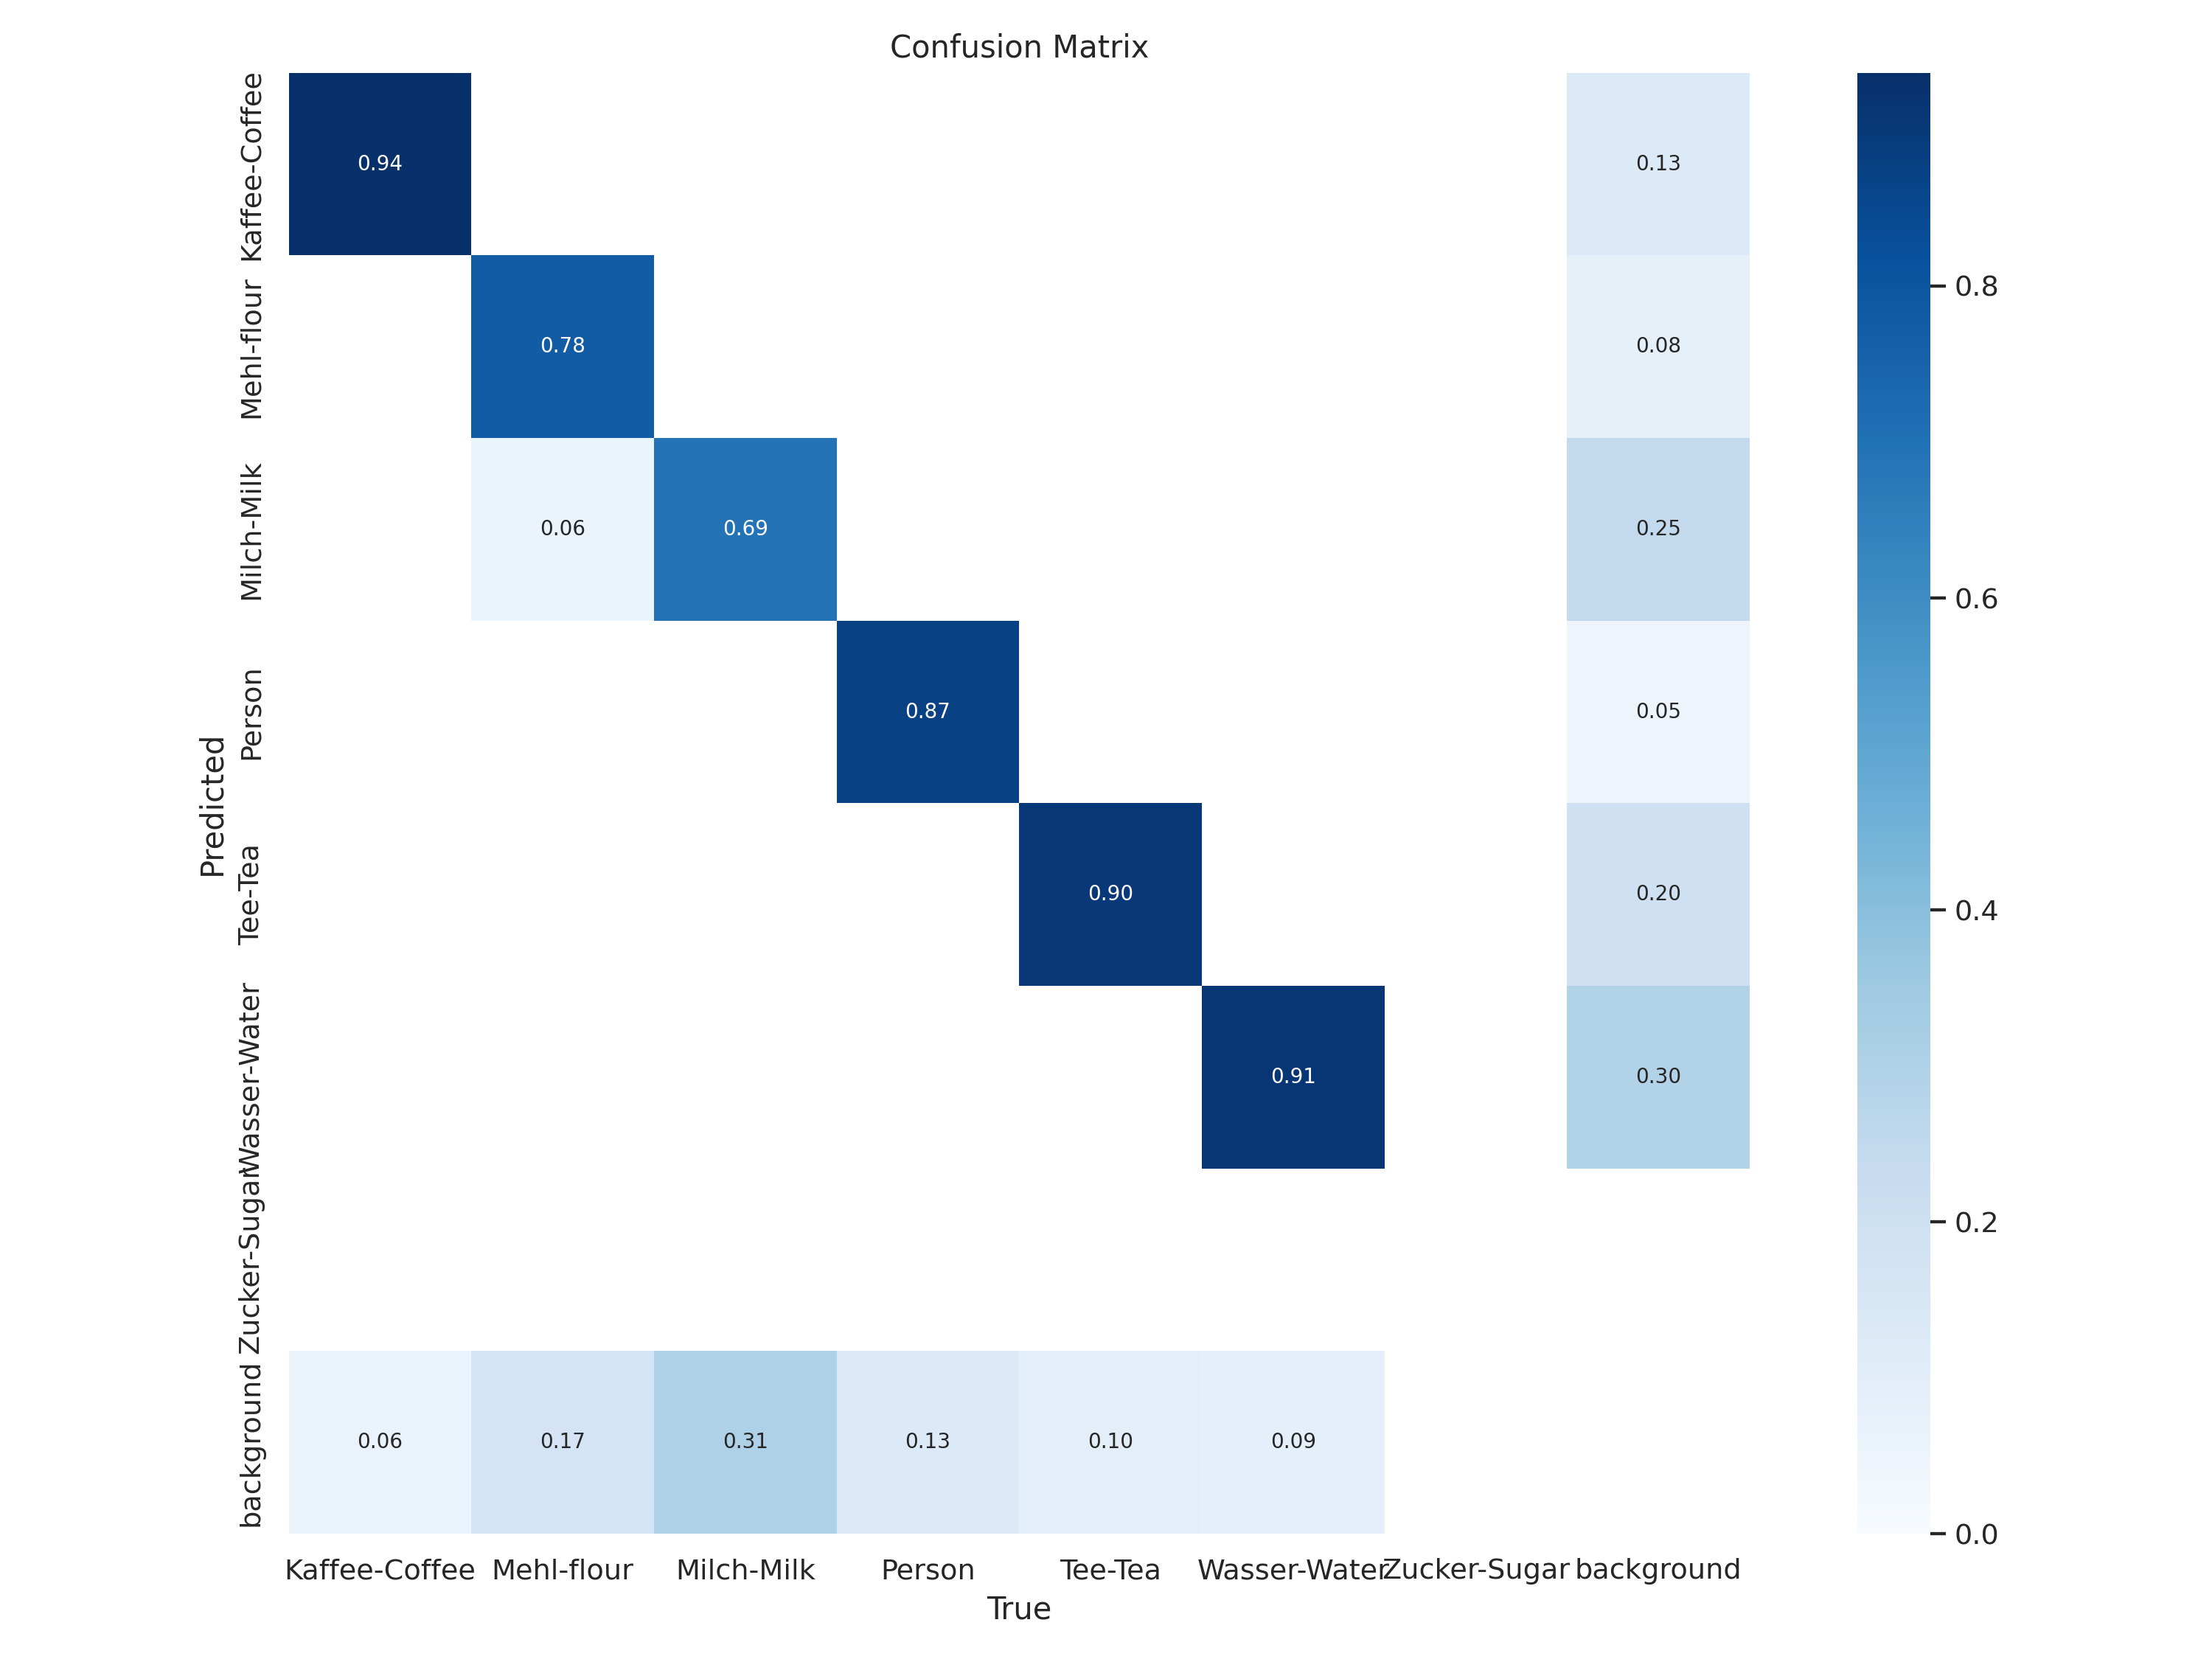

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)

/content


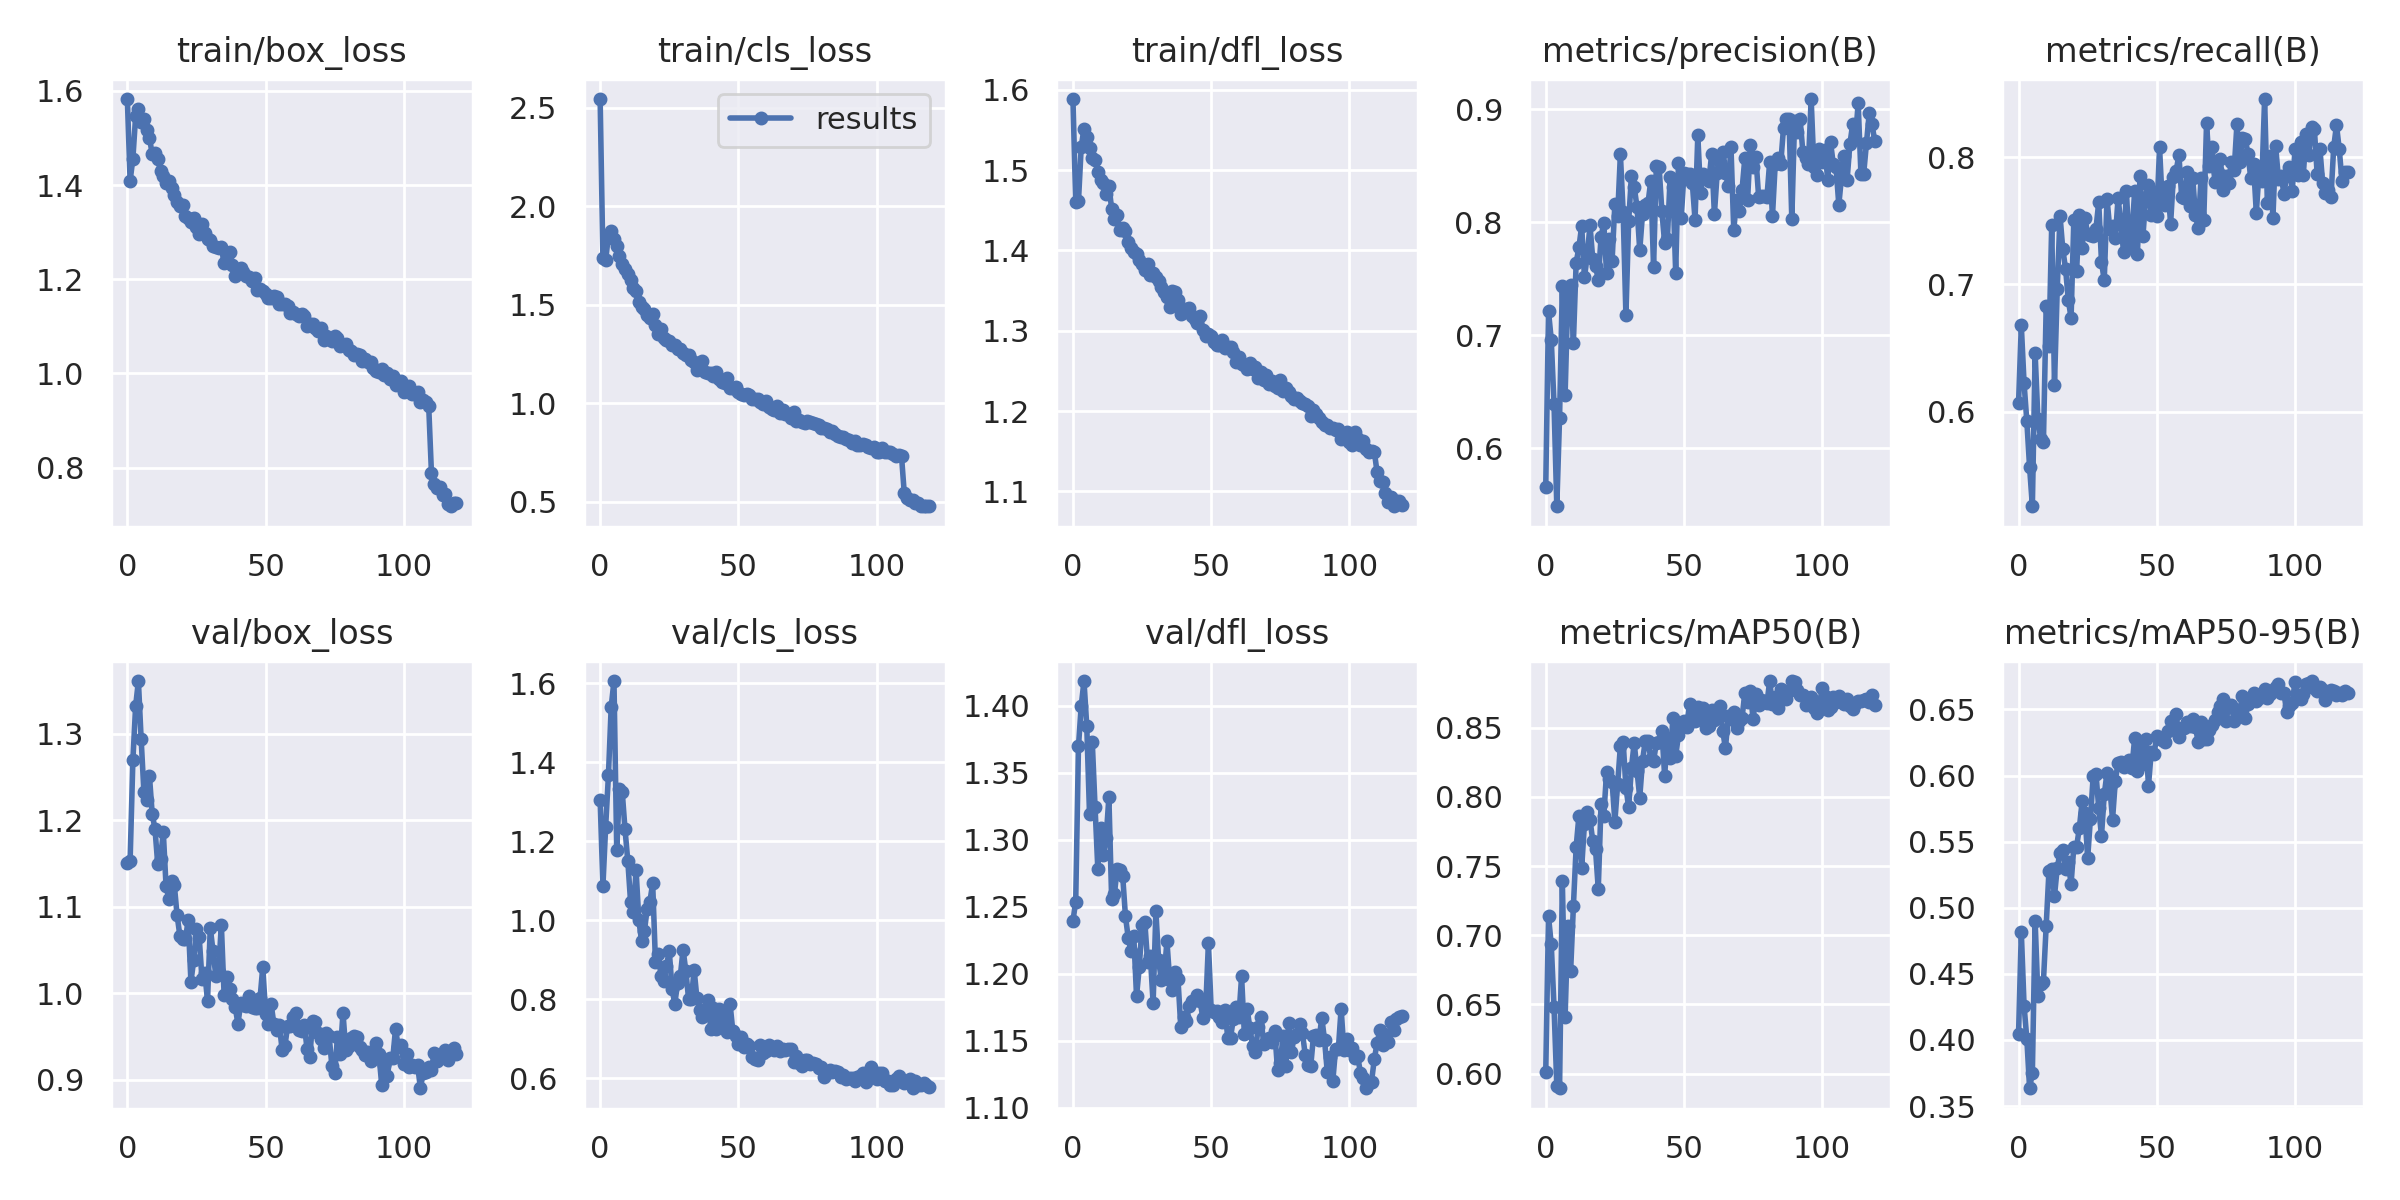

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/results.png', width=600)

/content


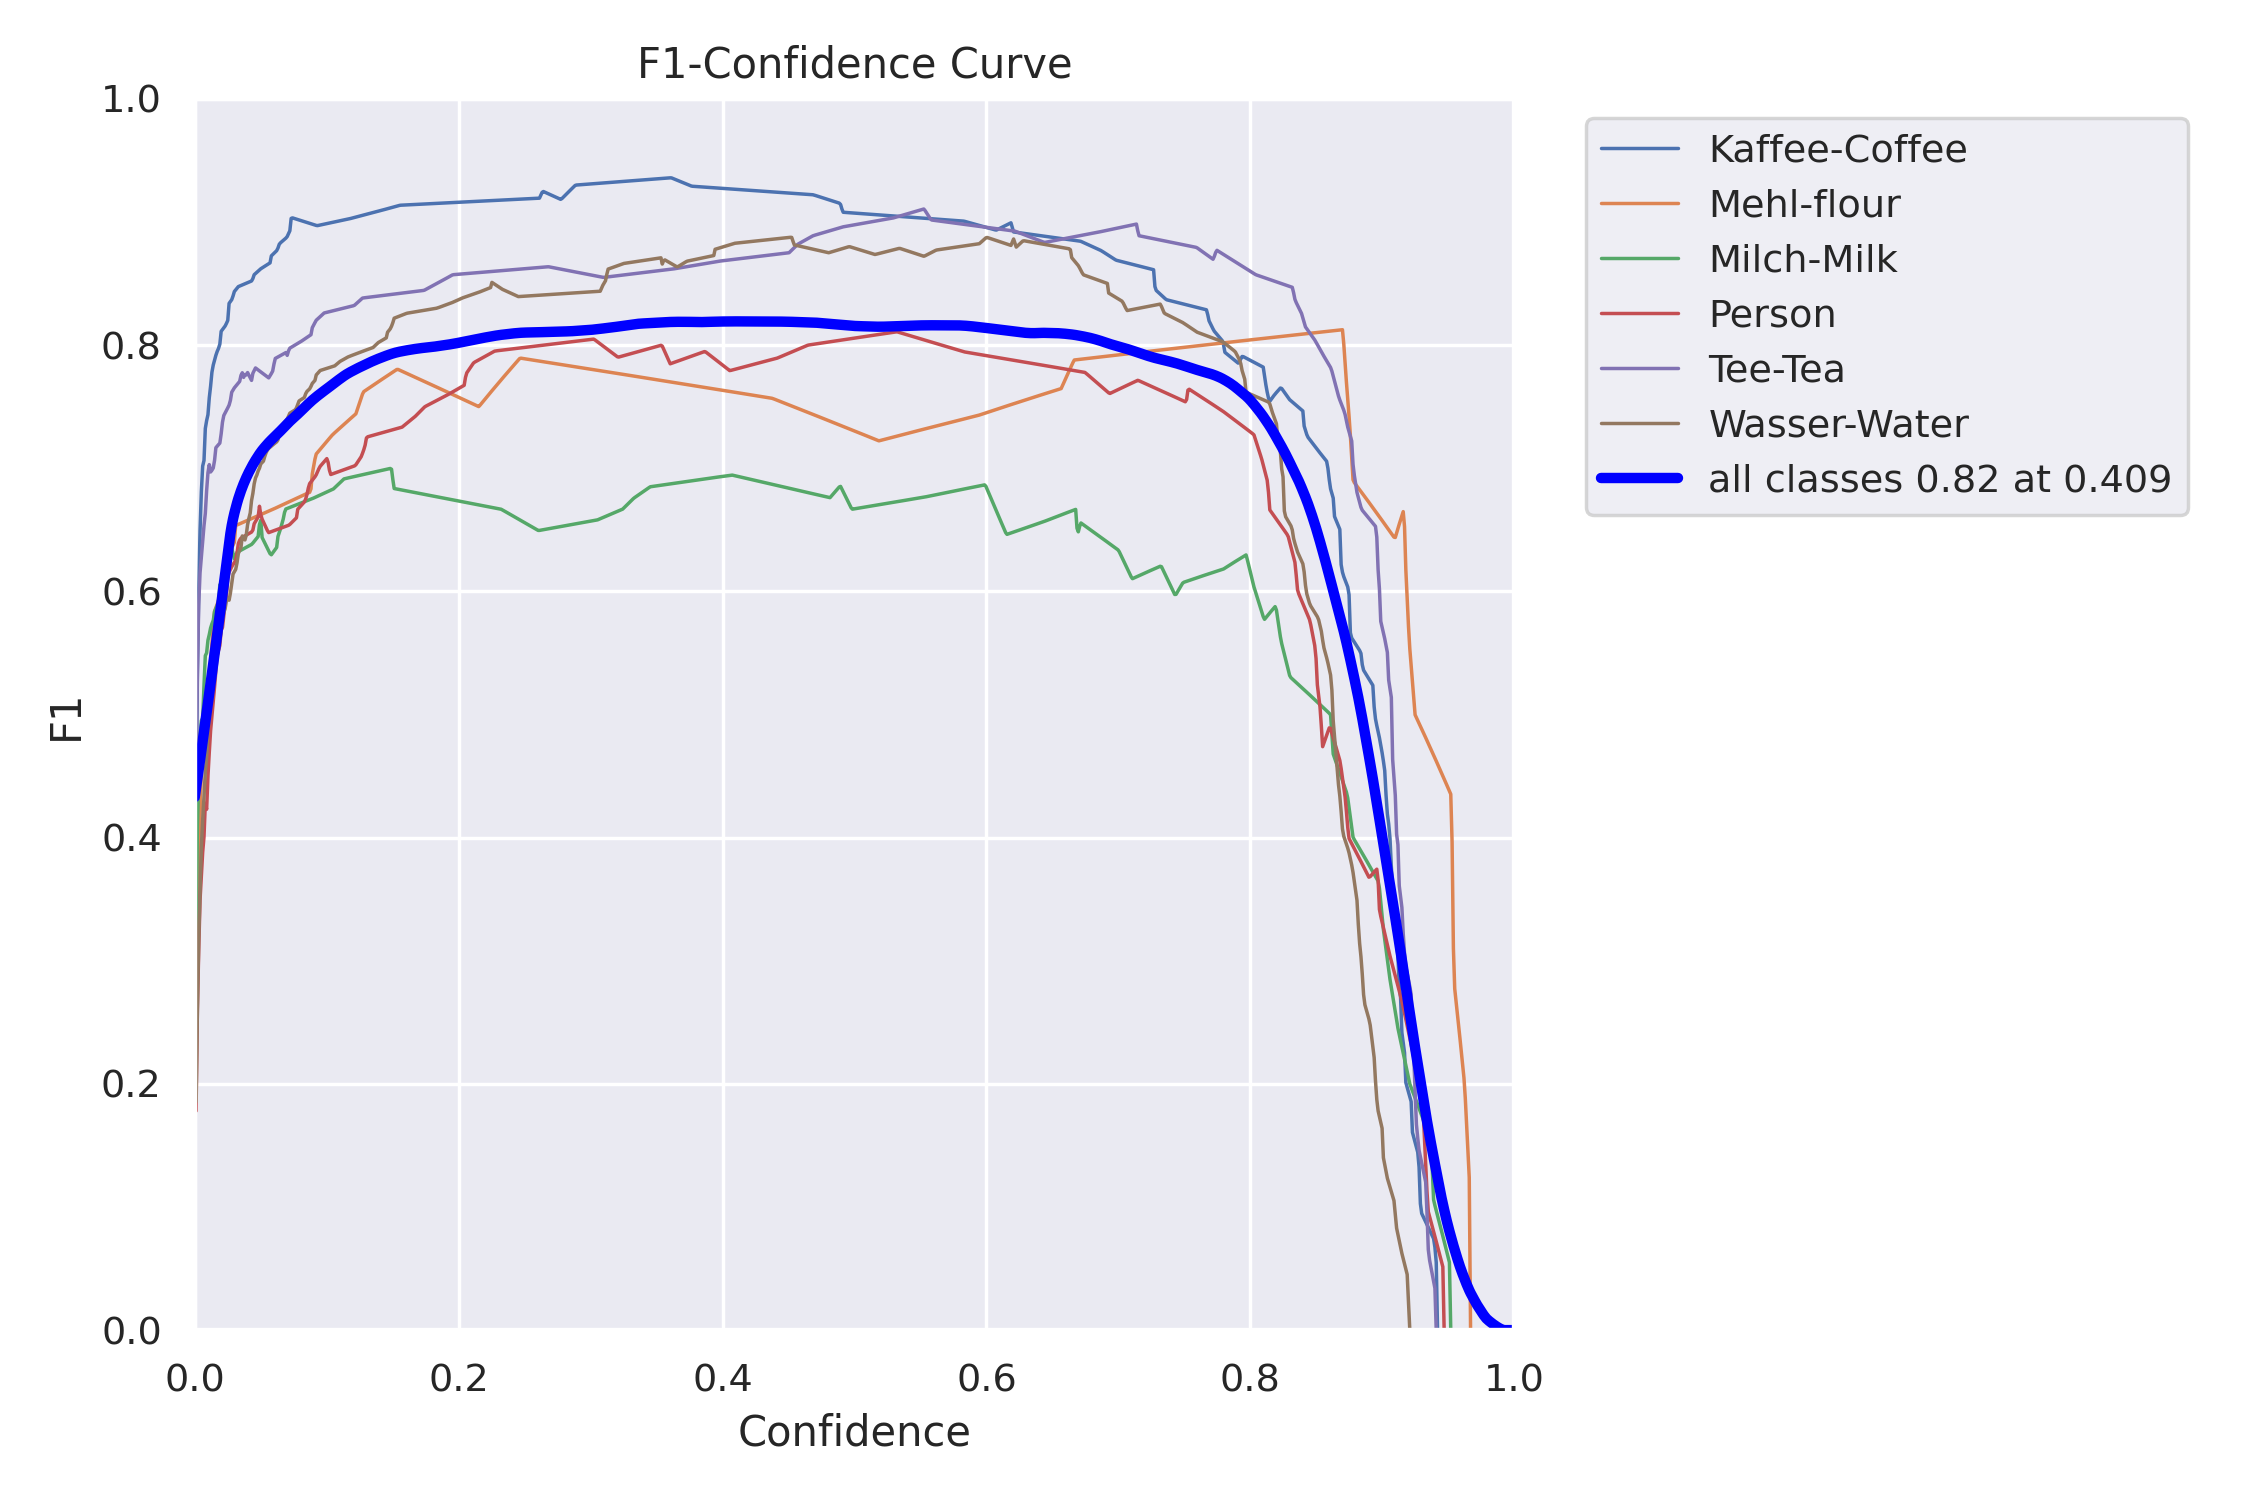

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/F1_curve.png', width=600)

/content


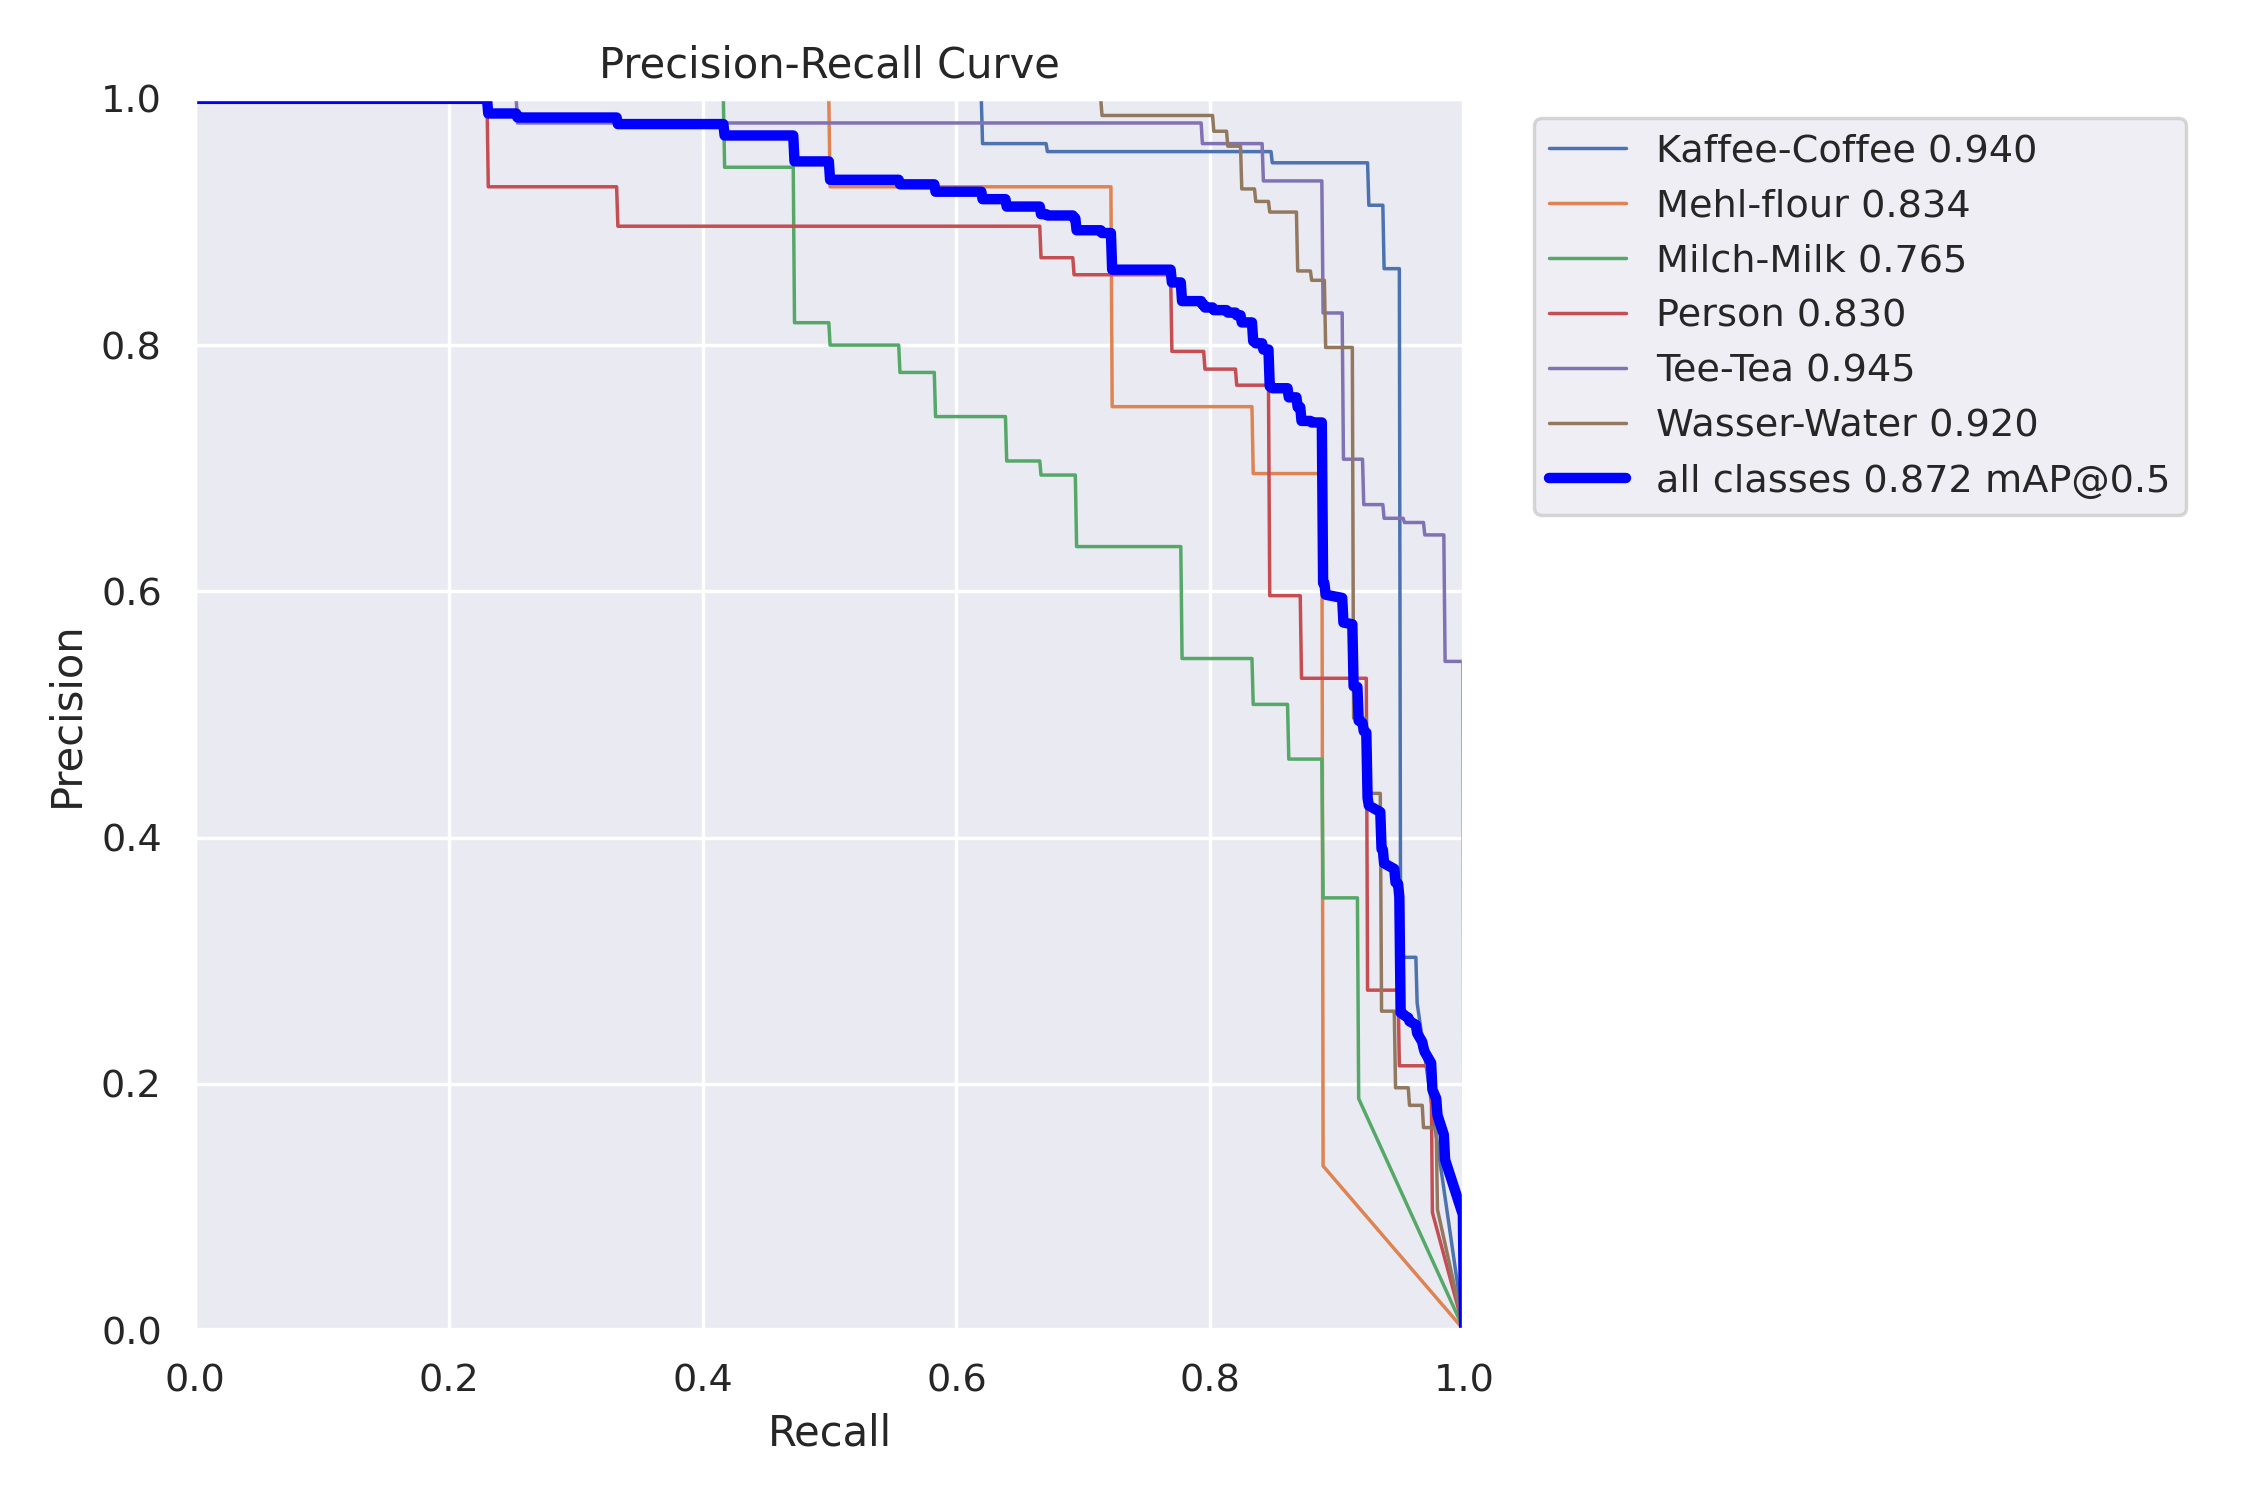

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/PR_curve.png', width=600)

/content


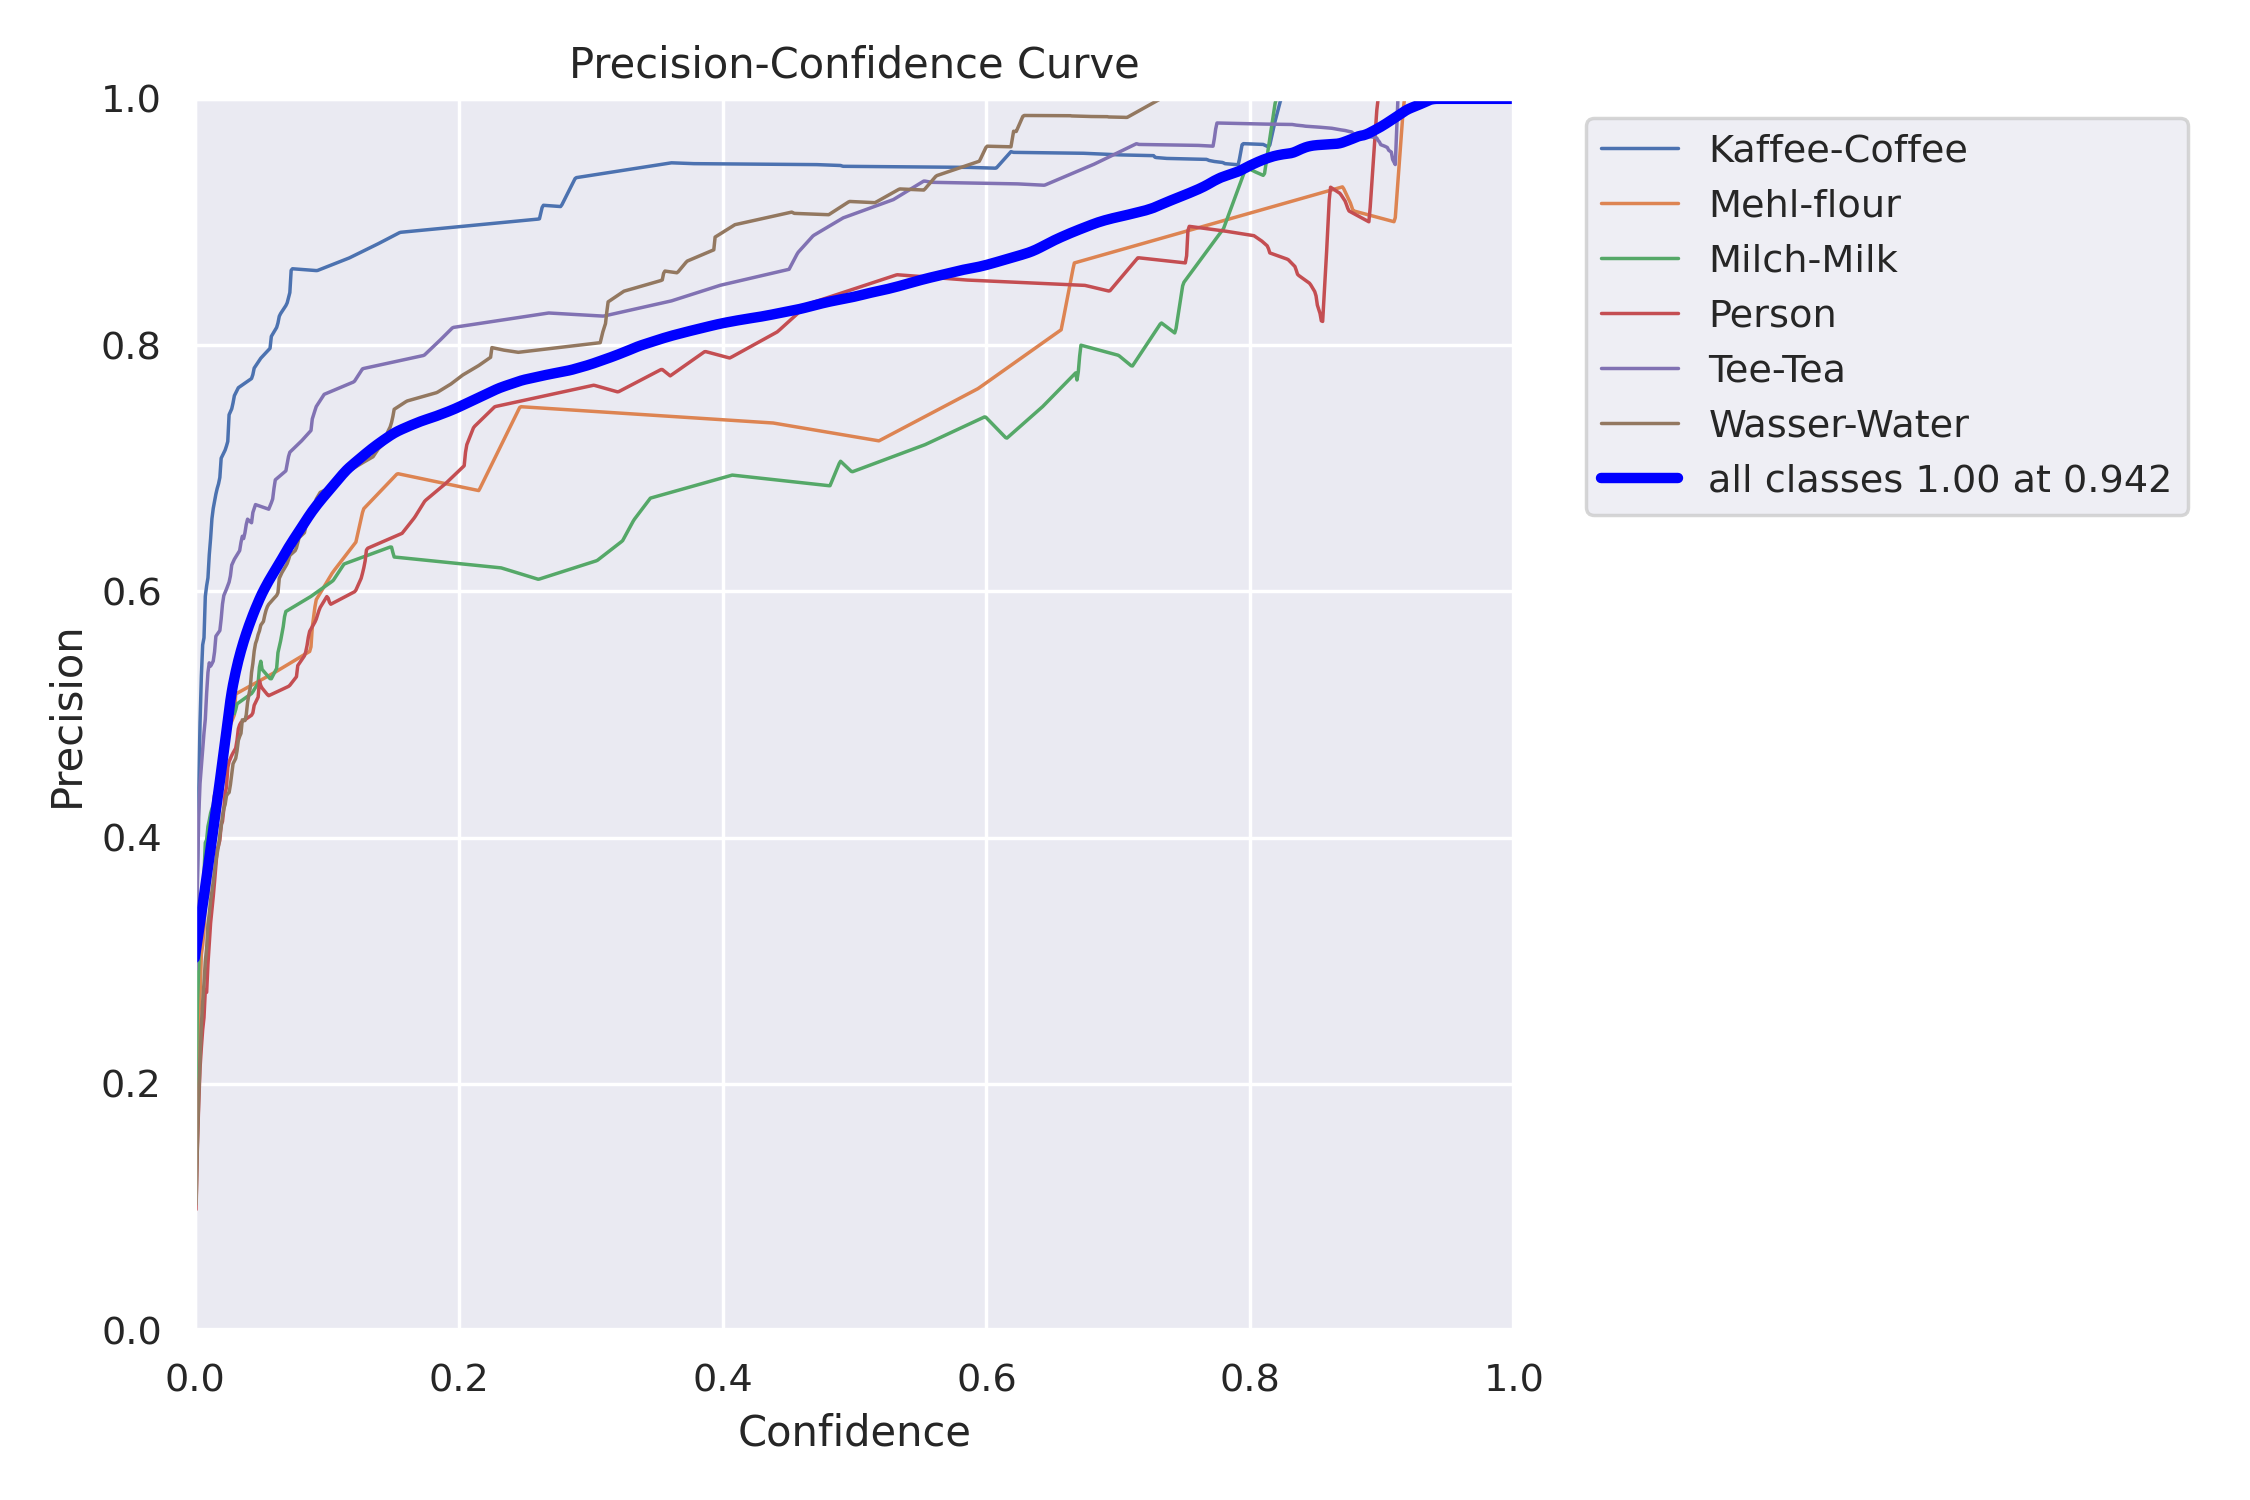

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/P_curve.png', width=600)

/content


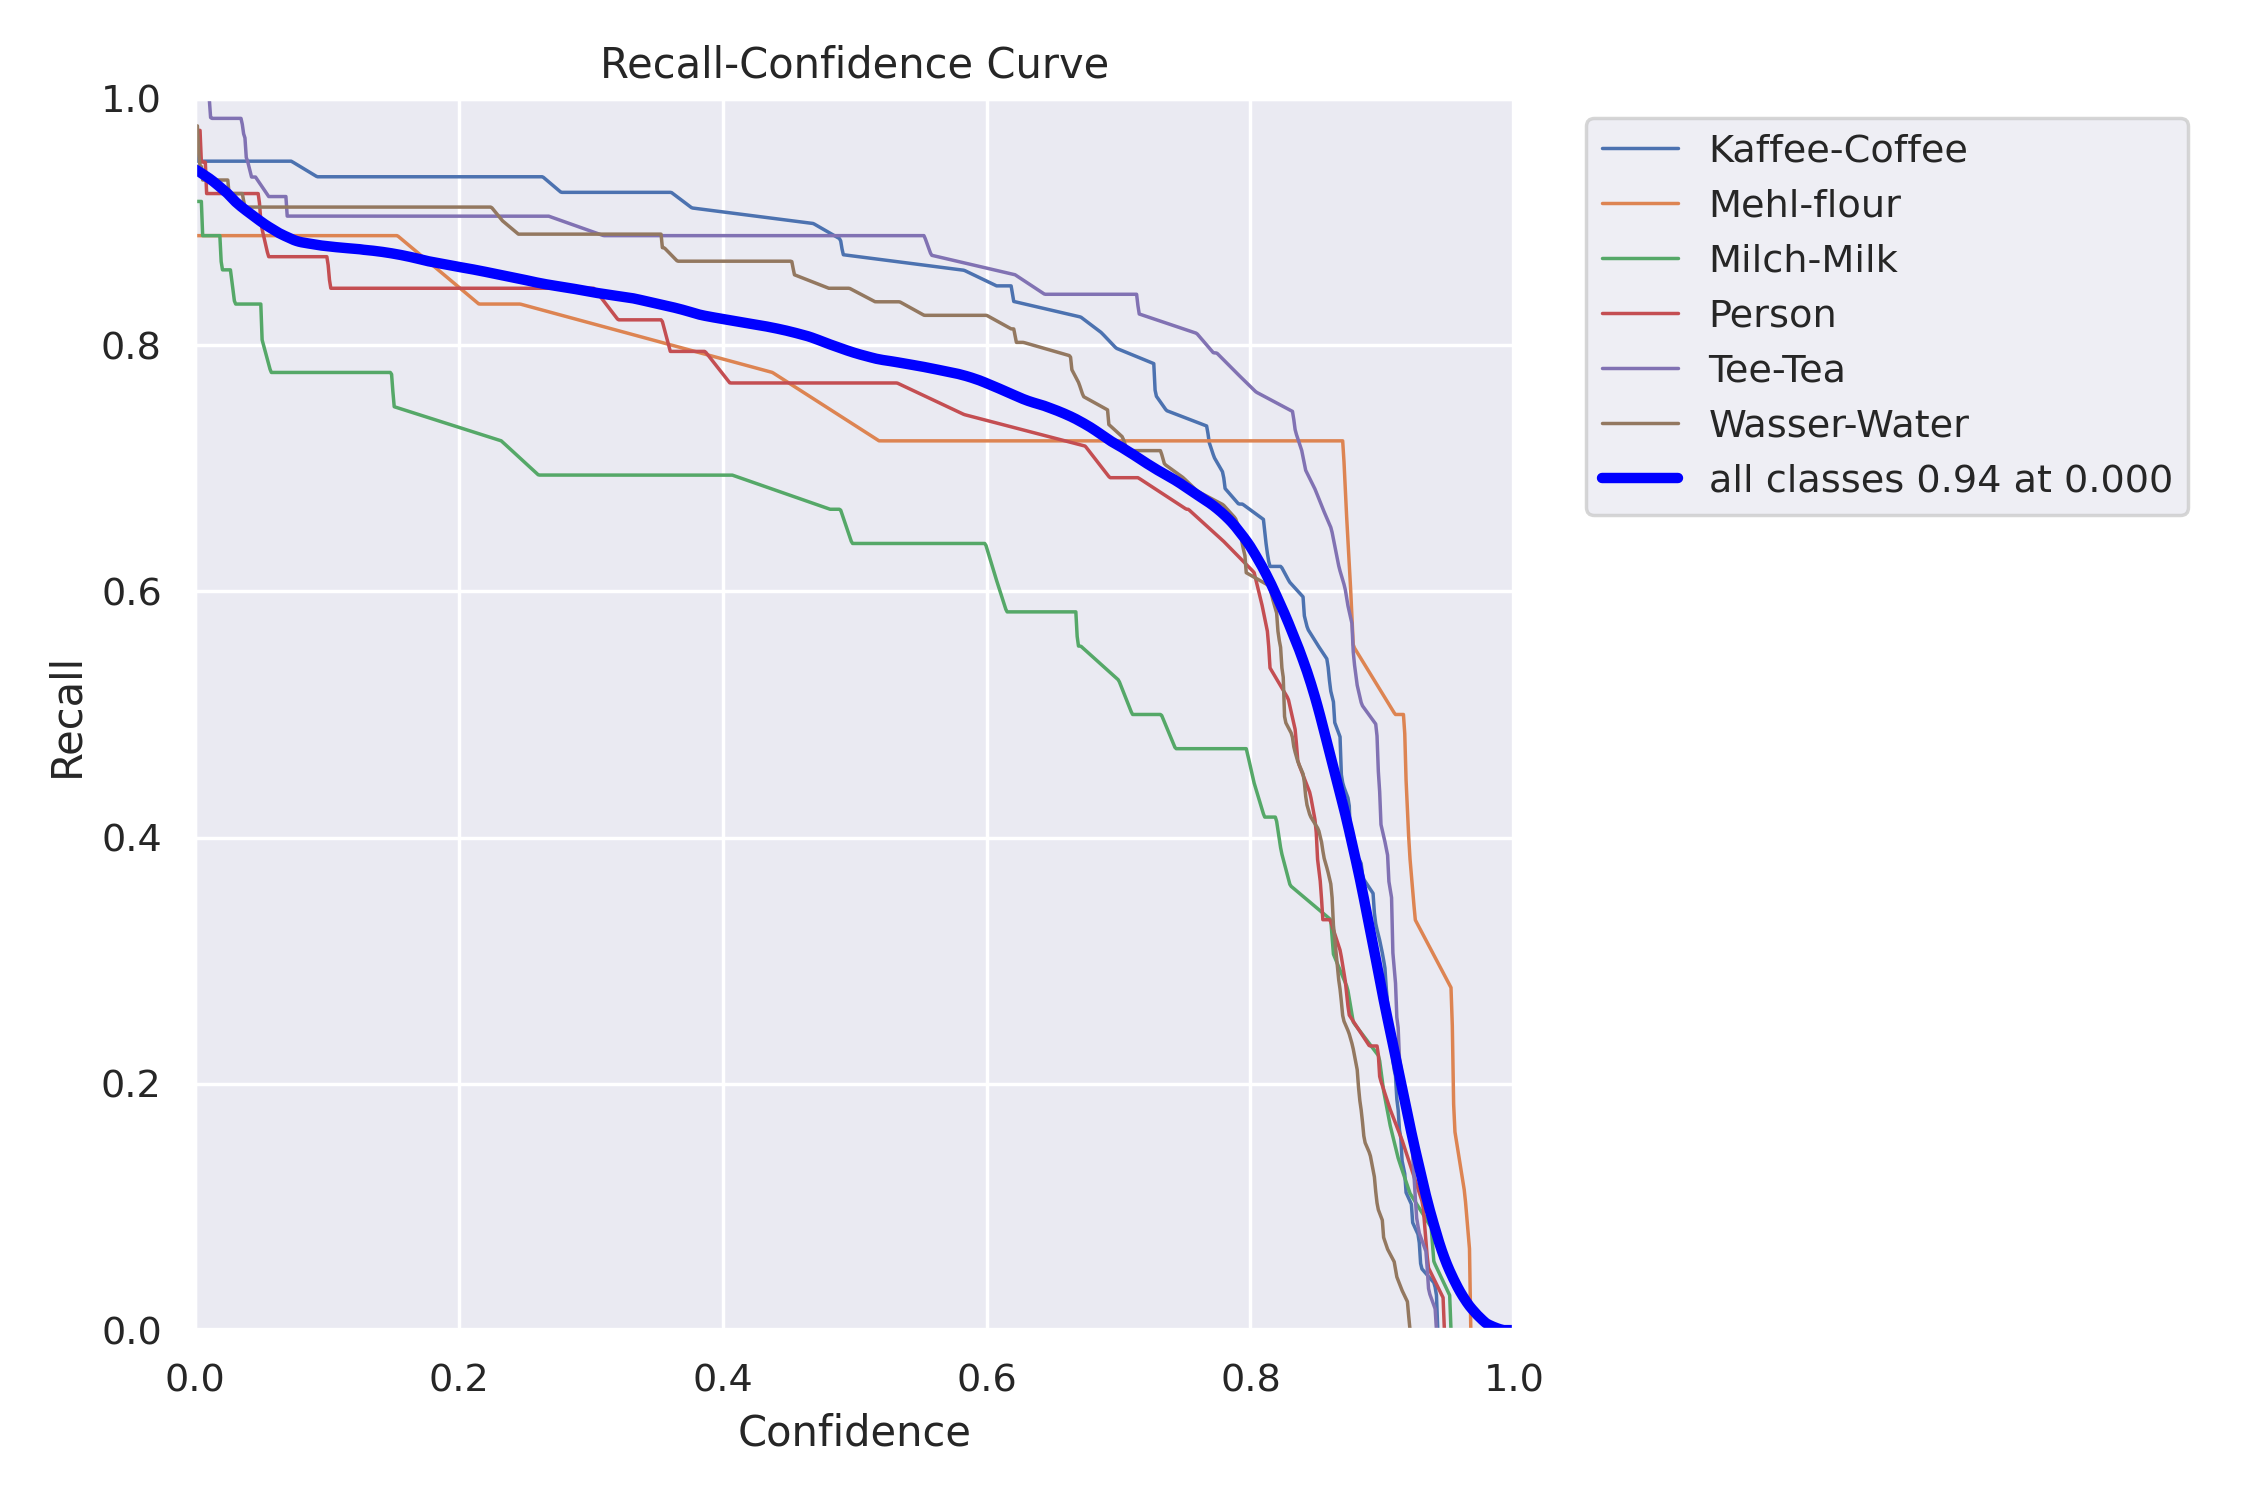

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/R_curve.png', width=600)

###Save Test Results

In [ ]:
%cd {HOME}
#model = YOLO("/content/runs/detect/train/weights/best.pt")
images = "/content/datasets/Market-Products-Detection-4/test/images/"
#num = 0
for image in os.listdir(images):
  full_path =  "/content/datasets/Market-Products-Detection-4/test/images/" + image
  absolute_path = os.path.abspath(full_path)
  !yolo task=detect mode=predict model="/content/runs/detect/train/weights/best.pt" conf=0.25 source="{images}{image}" save=True save_txt=True save_conf=True
  #!yolo task=detect mode=predict model="/content/best5.pt" conf=0.25 source="{images}{image}" save=True save_txt=True save_conf=True
  #num +=1
  #if num == 4:
    #break

/content
2023-09-28 18:57:37.351424: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-09-28 18:57:38.740880: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
Ultralytics YOLOv8.0.20 🚀 Python-3.10.12 torch-2.0.1+cu118 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 218 layers, 25843813 parameters, 0 gradients, 78.7 GFLOPs
image 1/1 /content/datasets/Market-Products-Detection-4/test/images/WATER0150_png.rf.b87ce38ae07c41d6b3d9c4a709d3cc99.jpg: 256x256 7 Wasser-Waters, 12.8ms
Speed: 0.4ms pre-process, 12.8ms inference, 87.6ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/predict
1 label saved to runs/detect/predict/labels
2023-09-28 18:57:46.622109: I tensorflow/core/platfo

###Functions for test results

In [ ]:
import glob

In [ ]:
def match_files(image):
  directory_to_search = "/content/datasets/Market-Products-Detection-4/test/labels"
  file_pattern = image
  matching_files = glob.glob(os.path.join(directory_to_search, file_pattern))
  if matching_files:
      return True
  else:
      return False

In [ ]:
def find_real_classes(image):
  file_path2 = "/content/datasets/Market-Products-Detection-4/test/labels/" + image
  classes = []
  with open(file_path2, "r") as file:
    for line in file:
      words = line.strip().split()  # Split the line into words
      first_word = words[0]
      if(find_class_name(first_word) not in classes):
        classes.append(find_class_name(first_word))
  return classes

In [ ]:
def find_class_name(classID):
  name = ""
  if(classID == "0"):
    name = "Kaffee/Coffee"
  elif(classID == "1"):
    name = "Mehl/Flour"
  elif(classID == "2"):
    name = "Milch/Milk"
  elif(classID == "4"):
    name = "Tee/Tea"
  elif(classID == "5"):
    name = "Wasser-Water"
  return name

In [ ]:
def find_detected_classes(directory, image):
  class_accuracy = {}
  file_path2 = file_path2 = directory + image
  with open(file_path2, "r") as file:
    with open(file_path, "r") as file:
      for line in file:
        words = line.strip().split()  # Split the line into words
        class_name = find_class_name(words[0])
        accuracy = words[-1]  # Get the last word
        if class_name in class_accuracy:
          if accuracy > class_accuracy[class_name]:
            class_accuracy[class_name] = (accuracy)
        else:
          class_accuracy[class_name] = (accuracy)
  return class_accuracy.items()
  """
  for accuracy in class_accuracy.items():
    print(accuracy)
  """


###Compare Actual Values and Test Results

In [ ]:
import pandas as pd
df = pd.DataFrame(columns=["Real Classes", "Predictions"])

In [ ]:
detections = "/content/runs/detect"
for predict in os.listdir(detections):
  if (predict != "train"):
    directory = predict + "/labels"
    if (os.path.isdir(detections + "/" + directory)):
      directory_contents = os.listdir(detections + "/" + directory)
      if directory_contents:
        for image in os.listdir(detections + "/" + directory):
          file_path = detections + "/" + directory + "/" + image
          if os.path.exists(file_path):
            with open(file_path, "r") as file:
              content = file.read()
            if match_files(image):
              classes = find_real_classes(image)
              directory2 = detections + "/" + directory + "/"
              detected_classes = find_detected_classes(directory2, image)
              new_row = {'Real Classes': classes, 'Predictions': detected_classes}
              # Append the new row to the DataFrame
              df = df.append(new_row, ignore_index=True)
      else:
        for image in os.listdir(detections + "/" + predict):
          if(image != "labels"):
            image = image.rsplit('.jpg', 1)[0] + '.txt'
            if(image != ".ipynb_checkpoints.txt"):
              classes = find_real_classes(image)
        new_row = {'Real Classes': classes, 'Predictions': [('no detections', 0)]}
        df = df.append(new_row, ignore_index=True)

The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
The frame.append method is deprecated and will be remove

In [ ]:
df.head(10)

,Real Classes,Predictions
0,[],"((, 0.766815))"
1,[Kaffee/Coffee],"((Kaffee/Coffee, 0.904417))"
2,[Wasser-Water],"((Wasser-Water, 0.852054))"
3,[Kaffee/Coffee],"((Kaffee/Coffee, 0.926152))"
4,[Mehl/Flour],"((Mehl/Flour, 0.932769))"
5,[Wasser-Water],"((Wasser-Water, 0.813644))"
6,[Kaffee/Coffee],"((Kaffee/Coffee, 0.851076))"
7,[Mehl/Flour],"((Mehl/Flour, 0.912809))"
8,[Tee/Tea],"((Tee/Tea, 0.890229))"
9,[],"((, 0.840016))"


###Plot Results

In [ ]:
for index, row in df.iterrows():
  real_classes = row['Real Classes']
  predictions = row['Predictions']


###Trial

In [ ]:
import pandas as pd
df = pd.DataFrame(columns=["Real Classes", "Predictions"])

In [ ]:
detections = "/content/runs/detect"
for predict in os.listdir(detections):
  if (predict != "train"):
    directory = predict + "/labels"
    if (os.path.isdir(detections + "/" + directory)):
      directory_contents = os.listdir(detections + "/" + directory)
      if directory_contents:
        for image in os.listdir(detections + "/" + directory):
          file_path = detections + "/" + directory + "/" + image
          if os.path.exists(file_path):
            with open(file_path, "r") as file:
              content = file.read()
            if match_files(image):
              classes = find_real_classes(image)
              directory2 = detections + "/" + directory + "/"
              detected_classes = find_detected_classes(directory2, image)
              new_row = {'Real Classes': classes, 'Predictions': detected_classes}
              # Append the new row to the DataFrame
              df = df.append(new_row, ignore_index=True)
      else:
        for image in os.listdir(detections + "/" + predict):
          if(image != "labels"):
            image = image.rsplit('.jpg', 1)[0] + '.txt'
            if(image != ".ipynb_checkpoints.txt"):
              classes = find_real_classes(image)
        prediction = {'no detections': 0}
        dict_items_view = prediction.items()
        new_row = {'Real Classes': classes, 'Predictions': dict_items_view}
        df = df.append(new_row, ignore_index=True)

The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
The frame.append method is deprecated and will be remove

In [ ]:
df

,Real Classes,Predictions
0,[],"((, 0.766815))"
1,[Kaffee/Coffee],"((Kaffee/Coffee, 0.904417))"
2,[Wasser-Water],"((Wasser-Water, 0.852054))"
3,[Kaffee/Coffee],"((Kaffee/Coffee, 0.926152))"
4,[Mehl/Flour],"((Mehl/Flour, 0.932769))"
...,...,...
117,[Milch/Milk],"((Milch/Milk, 0.926436))"
118,[Kaffee/Coffee],"((Kaffee/Coffee, 0.772419))"
119,[Wasser-Water],"((Wasser-Water, 0.867937))"
120,[Wasser-Water],"((Wasser-Water, 0.895446))"


In [ ]:
real_classes = []
predicted_classes2 = []
for index, row in df.iterrows():
  real_classes.append(row['Real Classes'])
  predicted_classes2.append(row['Predictions'])

In [ ]:
print(real_classes)
print(predicted_classes2)

[[''], ['Kaffee/Coffee'], ['Wasser-Water'], ['Kaffee/Coffee'], ['Mehl/Flour'], ['Wasser-Water'], ['Kaffee/Coffee'], ['Mehl/Flour'], ['Tee/Tea'], [''], ['Kaffee/Coffee'], ['Wasser-Water'], ['Wasser-Water'], ['Kaffee/Coffee'], [''], [], ['Kaffee/Coffee'], [], ['Milch/Milk'], ['Wasser-Water'], [''], [''], ['Wasser-Water'], ['Kaffee/Coffee'], ['Kaffee/Coffee'], ['Tee/Tea'], ['Kaffee/Coffee'], ['Wasser-Water'], ['Wasser-Water'], ['Wasser-Water'], [''], ['Wasser-Water'], ['Wasser-Water'], ['Wasser-Water'], ['Milch/Milk'], ['Kaffee/Coffee'], [''], ['Kaffee/Coffee'], ['Kaffee/Coffee'], ['Mehl/Flour'], ['Tee/Tea'], ['Wasser-Water'], ['Milch/Milk'], ['Wasser-Water'], ['Tee/Tea'], ['Milch/Milk'], ['Mehl/Flour'], ['Kaffee/Coffee'], [''], ['Wasser-Water'], ['Milch/Milk'], [''], ['Milch/Milk'], ['Wasser-Water'], ['Wasser-Water'], ['Wasser-Water'], ['Kaffee/Coffee'], ['Mehl/Flour'], ['Milch/Milk'], ['Wasser-Water'], [''], [''], ['Milch/Milk'], ['Tee/Tea'], [''], ['Tee/Tea'], ['Wasser-Water'], ['Wasse

In [ ]:
unique_predict = []
for predict in predicted_classes2:
    unique_classes = set(predict)
    unique_classes_list = list(unique_classes)
    unique_predict.append(unique_classes_list)
print(unique_predict)

[[('', '0.766815')], [('Kaffee/Coffee', '0.904417')], [('Wasser-Water', '0.852054')], [('Kaffee/Coffee', '0.926152')], [('Mehl/Flour', '0.932769')], [('Wasser-Water', '0.813644')], [('Kaffee/Coffee', '0.851076')], [('Mehl/Flour', '0.912809')], [('Tee/Tea', '0.890229')], [('', '0.840016')], [('Kaffee/Coffee', '0.699905')], [('Wasser-Water', '0.902934')], [('Wasser-Water', '0.875233')], [('Kaffee/Coffee', '0.93291')], [('', '0.577403')], [('Kaffee/Coffee', '0.860805')], [('Kaffee/Coffee', '0.905854')], [('', '0.907941')], [('Milch/Milk', '0.923734')], [('Wasser-Water', '0.903852'), ('Mehl/Flour', '0.462243')], [('', '0.816262')], [('', '0.836232')], [('Wasser-Water', '0.898523')], [('Kaffee/Coffee', '0.722309')], [('Kaffee/Coffee', '0.706571')], [('Kaffee/Coffee', '0.809352')], [('Kaffee/Coffee', '0.898267')], [('Wasser-Water', '0.897709')], [('Wasser-Water', '0.87132')], [('Wasser-Water', '0.927301')], [('', '0.853059')], [('Wasser-Water', '0.863373')], [('Wasser-Water', '0.857702')], [

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict

In [ ]:
print(real_classes)

[[''], ['Kaffee/Coffee'], ['Wasser-Water'], ['Kaffee/Coffee'], ['Mehl/Flour'], ['Wasser-Water'], ['Kaffee/Coffee'], ['Mehl/Flour'], ['Tee/Tea'], [''], ['Kaffee/Coffee'], ['Wasser-Water'], ['Wasser-Water'], ['Kaffee/Coffee'], [''], [], ['Kaffee/Coffee'], [], ['Milch/Milk'], ['Wasser-Water'], [''], [''], ['Wasser-Water'], ['Kaffee/Coffee'], ['Kaffee/Coffee'], ['Tee/Tea'], ['Kaffee/Coffee'], ['Wasser-Water'], ['Wasser-Water'], ['Wasser-Water'], [''], ['Wasser-Water'], ['Wasser-Water'], ['Wasser-Water'], ['Milch/Milk'], ['Kaffee/Coffee'], [''], ['Kaffee/Coffee'], ['Kaffee/Coffee'], ['Mehl/Flour'], ['Tee/Tea'], ['Wasser-Water'], ['Milch/Milk'], ['Wasser-Water'], ['Tee/Tea'], ['Milch/Milk'], ['Mehl/Flour'], ['Kaffee/Coffee'], [''], ['Wasser-Water'], ['Milch/Milk'], [''], ['Milch/Milk'], ['Wasser-Water'], ['Wasser-Water'], ['Wasser-Water'], ['Kaffee/Coffee'], ['Mehl/Flour'], ['Milch/Milk'], ['Wasser-Water'], [''], [''], ['Milch/Milk'], ['Tee/Tea'], [''], ['Tee/Tea'], ['Wasser-Water'], ['Wasse

In [ ]:
print(unique_predict)

[[('', '0.766815')], [('Kaffee/Coffee', '0.904417')], [('Wasser-Water', '0.852054')], [('Kaffee/Coffee', '0.926152')], [('Mehl/Flour', '0.932769')], [('Wasser-Water', '0.813644')], [('Kaffee/Coffee', '0.851076')], [('Mehl/Flour', '0.912809')], [('Tee/Tea', '0.890229')], [('', '0.840016')], [('Kaffee/Coffee', '0.699905')], [('Wasser-Water', '0.902934')], [('Wasser-Water', '0.875233')], [('Kaffee/Coffee', '0.93291')], [('', '0.577403')], [('Kaffee/Coffee', '0.860805')], [('Kaffee/Coffee', '0.905854')], [('', '0.907941')], [('Milch/Milk', '0.923734')], [('Wasser-Water', '0.903852'), ('Mehl/Flour', '0.462243')], [('', '0.816262')], [('', '0.836232')], [('Wasser-Water', '0.898523')], [('Kaffee/Coffee', '0.722309')], [('Kaffee/Coffee', '0.706571')], [('Kaffee/Coffee', '0.809352')], [('Kaffee/Coffee', '0.898267')], [('Wasser-Water', '0.897709')], [('Wasser-Water', '0.87132')], [('Wasser-Water', '0.927301')], [('', '0.853059')], [('Wasser-Water', '0.863373')], [('Wasser-Water', '0.857702')], [

['Mehl/Flour', 'Milch/Milk', 'Wasser-Water', 'Tee/Tea', 'Kaffee/Coffee']


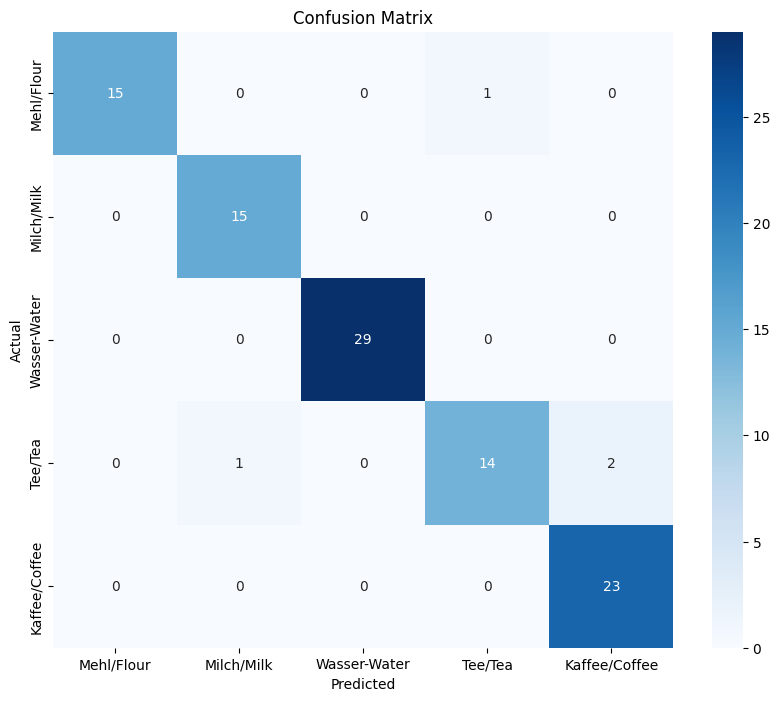

In [ ]:
# Flatten the real_classes and unique_predict lists
real_classes_flat = [item for sublist in real_classes for item in sublist]
predicted_classes_flat = [item[0] for sublist in unique_predict for item in sublist]

# Create a defaultdict to store confusion matrix data
confusion_dict = defaultdict(int)

# Populate the confusion_dict
for i in range(len(real_classes)):
  if(len(real_classes[i])>0):
    real_class = real_classes[i][0]
    predicted_class = unique_predict[i][0][0]
    if(real_class != ''):
      confusion_dict[(real_class, predicted_class)] += 1


# Create a list of unique classes
unique_classes = list(set(real_classes_flat + predicted_classes_flat))
(unique_classes)
unique_classes.remove(unique_classes[0])
print(unique_classes)
# Create an empty confusion matrix
confusion_matrix_data = []
for _ in range(len(unique_classes)):
    row = [0] * len(unique_classes)
    confusion_matrix_data.append(row)

# Populate the confusion matrix data
for actual_class, predicted_class in confusion_dict.keys():
    actual_index = unique_classes.index(actual_class)
    predicted_index = unique_classes.index(predicted_class)
    confusion_matrix_data[actual_index][predicted_index] = confusion_dict[(actual_class, predicted_class)]

# Convert confusion matrix data to a DataFrame for Seaborn visualization
confusion_df = pd.DataFrame(confusion_matrix_data, index=unique_classes, columns=unique_classes)

# Create a heatmap using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_df, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()